Imports

In [20]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import pickle
import os

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.11.0+cpu
Device: cpu


Generate synthetic sensor dataseter and a suite of new AI tools all in one bundle

In [21]:
def generate_synthetic_data(n_samples=20000, noise_std=3.0, seed=42):
    """
    Simulates an obstacle-avoidance expert policy.
    Features: [front_cm, left_cm, right_cm]
    Labels:   0=FORWARD, 1=LEFT, 2=RIGHT, 3=STOP
    """
    rng = np.random.default_rng(seed)
    front = rng.uniform(5, 200, n_samples)
    left  = rng.uniform(5, 200, n_samples)
    right = rng.uniform(5, 200, n_samples)

    labels = np.zeros(n_samples, dtype=np.int64)
    for i in range(n_samples):
        f, l, r = front[i], left[i], right[i]
        if f > 40:
            labels[i] = 0  # FORWARD
        else:
            if l > r and l > 20:
                labels[i] = 1  # LEFT
            elif r > l and r > 20:
                labels[i] = 2  # RIGHT
            elif l > 20:
                labels[i] = 1  # LEFT
            elif r > 20:
                labels[i] = 2  # RIGHT
            else:
                labels[i] = 3  # STOP

    # Add sensor noise
    front = np.clip(front + rng.normal(0, noise_std, n_samples), 2, None)
    left  = np.clip(left  + rng.normal(0, noise_std, n_samples), 2, None)
    right = np.clip(right + rng.normal(0, noise_std, n_samples), 2, None)

    df = pd.DataFrame({
        "front_cm": front,
        "left_cm":  left,
        "right_cm": right,
        "action":   labels
    })
    return df


# Generate and save
df = generate_synthetic_data(n_samples=20000)
df.to_csv("sensor_data.csv", index=False)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nLabel distribution (0=FWD,1=LEFT,2=RIGHT,3=STOP):")
print(df["action"].value_counts().sort_index())

Dataset shape: (20000, 4)

First 5 rows:
     front_cm     left_cm    right_cm  action
0  158.297426  148.762722   60.327692       0
1   87.553137  201.053840   28.657235       0
2  180.006227   11.807563   27.343370       0
3  137.649681   51.097583    6.013794       0
4   26.400798  119.491409  197.601360       2

Label distribution (0=FWD,1=LEFT,2=RIGHT,3=STOP):
action
0    16396
1     1779
2     1792
3       33
Name: count, dtype: int64


Quick visual sanity check

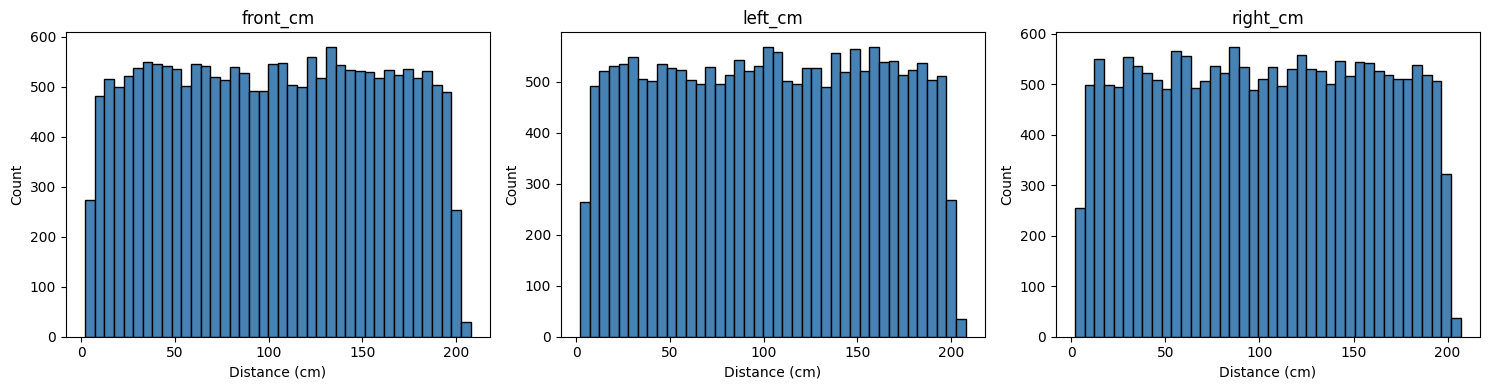

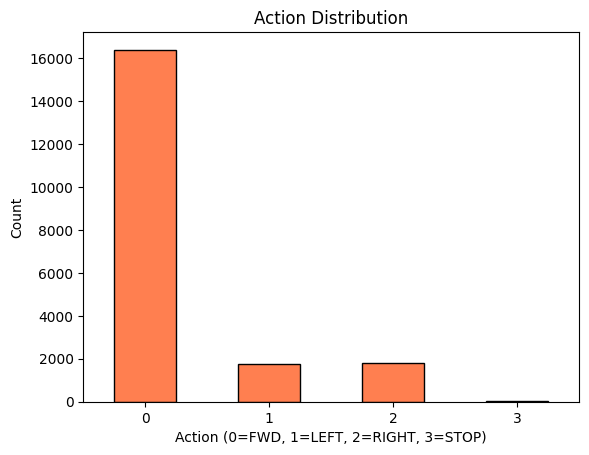

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["front_cm", "left_cm", "right_cm"]):
    ax.hist(df[col], bins=40, color="steelblue", edgecolor="black")
    ax.set_title(col)
    ax.set_xlabel("Distance (cm)")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# Action distribution
df["action"].value_counts().sort_index().plot(
    kind="bar", color="coral", edgecolor="black"
)
plt.title("Action Distribution")
plt.xlabel("Action (0=FWD, 1=LEFT, 2=RIGHT, 3=STOP)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Balance the classes before splitting

In [23]:
from sklearn.utils import resample

# Separate by class
df_majority = df[df.action == 0]     # FORWARD
df_left     = df[df.action == 1]
df_right    = df[df.action == 2]
df_stop     = df[df.action == 3]

# Oversample the small classes to at least 3000 each
target_n = 3000

def oversample(sub, n):
    if len(sub) >= n:
        return sub
    return resample(sub, replace=True, n_samples=n, random_state=42)

df_balanced = pd.concat([
    df_majority,
    oversample(df_left,  target_n),
    oversample(df_right, target_n),
    oversample(df_stop,  target_n),
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced dataset shape:", df_balanced.shape)
print(df_balanced["action"].value_counts().sort_index())

# Now reassign and continue with Cell 4's original code
df = df_balanced

Balanced dataset shape: (25396, 4)
action
0    16396
1     3000
2     3000
3     3000
Name: count, dtype: int64


Preprocessing

In [24]:
X = df[["front_cm", "left_cm", "right_cm"]].values.astype(np.float32)
y = df["action"].values.astype(np.int64)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)

# Save scaler for later use on the robot
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# To tensors
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_val_t   = torch.tensor(X_val)
y_val_t   = torch.tensor(y_val)

print("Train size:", X_train_t.shape, " Val size:", X_val_t.shape)
print("Scaler mean:", scaler.mean_)
print("Scaler std: ", scaler.scale_)

Train size: torch.Size([20316, 3])  Val size: torch.Size([5080, 3])
Scaler mean: [85.04336435 92.2533028  92.09996966]
Scaler std:  [60.13848758 60.25188118 60.35131593]


Model definition

In [25]:
class AvoiderNet(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64, num_actions=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_actions)
        )
    def forward(self, x):
        return self.net(x)


model = AvoiderNet()
print(model)
print("\nTotal parameters:",
      sum(p.numel() for p in model.parameters()))

AvoiderNet(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)

Total parameters: 4676


Training loop

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
X_train_t = X_train_t.to(device); y_train_t = y_train_t.to(device)
X_val_t   = X_val_t.to(device);   y_val_t   = y_val_t.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

EPOCHS = 100
BATCH_SIZE = 256

train_losses, val_losses, val_accs = [], [], []

for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(X_train_t.size(0))
    epoch_loss = 0.0
    n_batches = 0
    for i in range(0, X_train_t.size(0), BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        xb, yb = X_train_t[idx], y_train_t[idx]

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1

    avg_train_loss = epoch_loss / n_batches

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_loss = criterion(val_logits, y_val_t).item()
        preds = val_logits.argmax(dim=1)
        acc = (preds == y_val_t).float().mean().item()

    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    val_accs.append(acc)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"train_loss={avg_train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | "
              f"val_acc={acc:.4f}")

print("\nTraining complete.")

Epoch   1/100 | train_loss=0.7664 | val_loss=0.3091 | val_acc=0.9337
Epoch  10/100 | train_loss=0.0590 | val_loss=0.0576 | val_acc=0.9799
Epoch  20/100 | train_loss=0.0477 | val_loss=0.0462 | val_acc=0.9815
Epoch  30/100 | train_loss=0.0445 | val_loss=0.0436 | val_acc=0.9833
Epoch  40/100 | train_loss=0.0436 | val_loss=0.0428 | val_acc=0.9833
Epoch  50/100 | train_loss=0.0436 | val_loss=0.0435 | val_acc=0.9827
Epoch  60/100 | train_loss=0.0433 | val_loss=0.0428 | val_acc=0.9817
Epoch  70/100 | train_loss=0.0428 | val_loss=0.0448 | val_acc=0.9839
Epoch  80/100 | train_loss=0.0420 | val_loss=0.0423 | val_acc=0.9829
Epoch  90/100 | train_loss=0.0414 | val_loss=0.0422 | val_acc=0.9823
Epoch 100/100 | train_loss=0.0413 | val_loss=0.0428 | val_acc=0.9825

Training complete.


Training curves

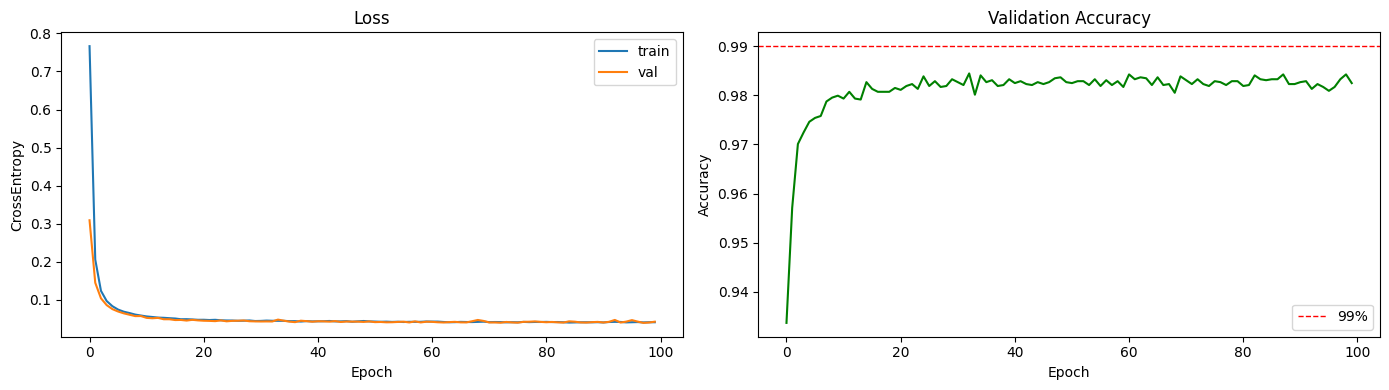

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(train_losses, label="train")
ax1.plot(val_losses, label="val")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("CrossEntropy")
ax1.legend()

ax2.plot(val_accs, color="green")
ax2.set_title("Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.axhline(0.99, color="red", linestyle="--", linewidth=1, label="99%")
ax2.legend()

plt.tight_layout()
plt.show()

Evaluation

Final validation accuracy: 0.9824803149606299

Classification report:
              precision    recall  f1-score   support

     FORWARD       0.99      0.99      0.99      3280
        LEFT       0.97      0.95      0.96       600
       RIGHT       0.95      0.96      0.95       600
        STOP       1.00      1.00      1.00       600

    accuracy                           0.98      5080
   macro avg       0.98      0.97      0.98      5080
weighted avg       0.98      0.98      0.98      5080



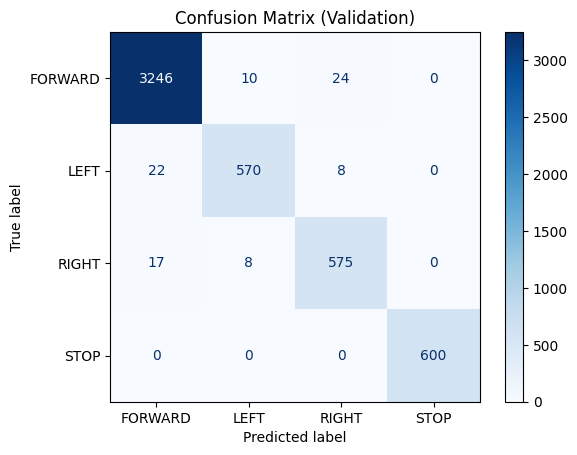

In [28]:
model.eval()
with torch.no_grad():
    val_logits = model(X_val_t)
    preds = val_logits.argmax(dim=1).cpu().numpy()
    y_true = y_val_t.cpu().numpy()

print("Final validation accuracy:",
      (preds == y_true).mean())

print("\nClassification report:")
print(classification_report(
    y_true, preds,
    target_names=["FORWARD", "LEFT", "RIGHT", "STOP"]
))

cm = confusion_matrix(y_true, preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["FORWARD", "LEFT", "RIGHT", "STOP"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Validation)")
plt.show()

Save trained model

In [29]:
torch.save(model.state_dict(), "avoider_model.pt")
print("Model saved -> avoider_model.pt")
print("Scaler saved -> scaler.pkl")
print("Dataset saved -> sensor_data.csv")

# Show files present
for f in ["sensor_data.csv", "scaler.pkl", "avoider_model.pt"]:
    print(f, "exists:", os.path.exists(f))

Model saved -> avoider_model.pt
Scaler saved -> scaler.pkl
Dataset saved -> sensor_data.csv
sensor_data.csv exists: True
scaler.pkl exists: True
avoider_model.pt exists: True


Run inference on sample sensor readings

In [30]:
ACTIONS = ["FORWARD", "LEFT", "RIGHT", "STOP"]

def predict(front, left, right):
    x = np.array([[front, left, right]], dtype=np.float32)
    x = scaler.transform(x).astype(np.float32)
    x = torch.tensor(x).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        idx = int(probs.argmax())
    return ACTIONS[idx], probs


# Test cases
test_cases = [
    (150, 150, 150, "Clear path ahead -> expect FORWARD"),
    (15,  120, 30,  "Obstacle ahead, more room left -> expect LEFT"),
    (15,  30,  120, "Obstacle ahead, more room right -> expect RIGHT"),
    (10,  10,  10,  "Boxed in on all sides -> expect STOP"),
    (5,   80,  80,  "Very close obstacle, both sides open -> LEFT or RIGHT"),
]

print(f"{'front':>6} {'left':>6} {'right':>6}  -> {'pred':<8} probs")
print("-" * 65)
for f, l, r, note in test_cases:
    pred, probs = predict(f, l, r)
    prob_str = " ".join(f"{p:.2f}" for p in probs)
    print(f"{f:>6} {l:>6} {r:>6}  -> {pred:<8} [{prob_str}]   # {note}")

 front   left  right  -> pred     probs
-----------------------------------------------------------------
   150    150    150  -> FORWARD  [1.00 0.00 0.00 0.00]   # Clear path ahead -> expect FORWARD
    15    120     30  -> LEFT     [0.00 1.00 0.00 0.00]   # Obstacle ahead, more room left -> expect LEFT
    15     30    120  -> RIGHT    [0.00 0.00 1.00 0.00]   # Obstacle ahead, more room right -> expect RIGHT
    10     10     10  -> STOP     [0.00 0.00 0.00 1.00]   # Boxed in on all sides -> expect STOP
     5     80     80  -> RIGHT    [0.00 0.36 0.64 0.00]   # Very close obstacle, both sides open -> LEFT or RIGHT


In [17]:
from google.colab import files
files.download("sensor_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
from google.colab import files
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
from google.colab import files
files.download("avoider_model.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>